In [1]:
import pandas as pd
import json
import numpy as np
from matplotlib import pyplot as plt
from pathlib import Path

In [2]:
with open("queries_and_videos.json", "r") as f:
    queries_and_videos = json.load(f)

In [3]:
queries = [q for cat in queries_and_videos for q in queries_and_videos[cat]]
len(queries)

133

In [4]:
associated_videos = [v for cat in queries_and_videos for q, v in queries_and_videos[cat].items()]
associated_videos_flat = [v for video_list in associated_videos for v in video_list]
len(set(associated_videos_flat))

2865

In [5]:
queries_videos_df = pd.concat([pd.DataFrame({"queries": list(queries_and_videos[cat].keys()), "videos": list(np.array(q) for q in queries_and_videos[cat].values()), "category": [cat for _ in range(len(queries_and_videos[cat].keys()))]}) for cat in queries_and_videos])
queries_videos_df["nb_videos"] = queries_videos_df["videos"].apply(lambda d: len(d))
queries_videos_df["nb_videos"].describe()

count     133.000000
mean      108.917293
std       330.238001
min         0.000000
25%         6.000000
50%        18.000000
75%        68.000000
max      2399.000000
Name: nb_videos, dtype: float64

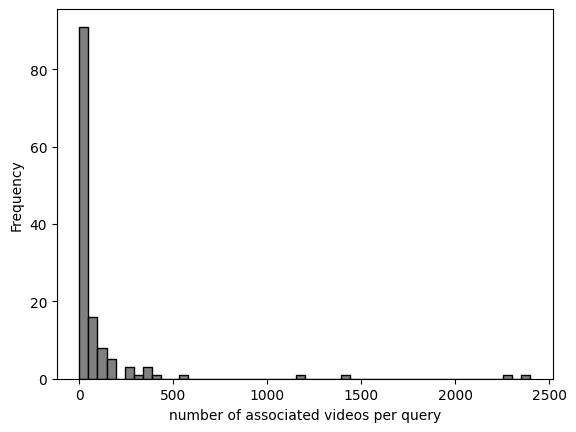

12 queries with no video associated to them


In [6]:
queries_videos_df["nb_videos"].plot(kind="hist", bins=50, color="grey", edgecolor="k")
plt.xlabel("number of associated videos per query")
plt.show()
print(len(queries_videos_df[queries_videos_df["nb_videos"] == 0]), "queries with no video associated to them")

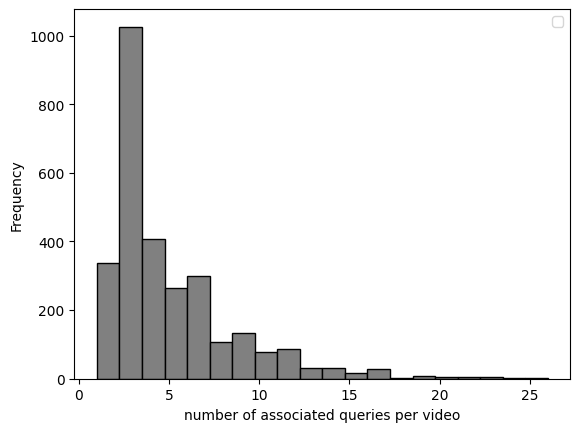

In [7]:
queries_videos_df.explode("videos").groupby("videos").agg({"queries": pd.Series.nunique}).plot(kind="hist", bins=20, color="grey", edgecolor="k")
plt.legend("")
plt.xlabel("number of associated queries per video")
plt.show()

In [8]:
queries_videos_df.sort_values("nb_videos")

,queries,videos,category,nb_videos
12,A fox sniffing while foraging.,[],RARE,0
13,A fox chasing prey.,[],RARE,0
9,A chamois resting.,[],RARE,0
8,A juvenile roe deer preparing to suckle.,[],RARE,0
24,A juvenile red deer shaking its head or body.,[],RARE,0
...,...,...,...,...
30,An animal being vigilant while the weather is ...,"[S3_C3_E501_V0277, S3_C3_E525_V0340, S3_C3_E52...",SOCIAL,573
0,A single adult red deer foraging only.,"[S3_C3_E545_V0423, S3_C3_E525_V0343, S3_C3_E54...",COMMON,1183
0,An animal engaged in any activity other than f...,"[S3_C3_E501_V0277, S3_C3_E523_V0324, S3_C3_E54...",RARE,1439
19,An individual sharing at least one activity wi...,"[S3_C3_E501_V0277, S3_C3_E525_V0340, S3_C3_E52...",VIDEO_COMPARISON,2282


In [9]:
queries_videos_df.explode("videos").groupby("videos").agg({"queries": pd.Series.nunique}).sort_values("queries")

,queries
videos,
S1_C1_E105_V0301,1
S1_C1_E105_V0302,1
S3_C3_E545_V0400,1
S3_C3_E524_V0331,1
S1_C5_F204_V0290,1
...,...
S3_C3_E693_V0703,23
S3_C3_E444_V0123,23
S3_C3_E455_V0170,23


In [10]:
print(*queries_videos_df.explode("videos").query("videos == 'S2_C3_F625_V0155'")["queries"].unique(), sep="\n")

An animal doing any other activity than foraging.
An animal running.
An animal browsing.
An adult red deer browsing.
A red deer browsing.
An animal running while foraging.
A video of two or more animals.
A video of three or more red deer.
A video of two female adult red deer walking while foraging.
An adult female red deer foraging and a juvenile red deer foraging.
A video of two or more juvenile red deer.
Two or more red deer foraging and at least one is also in vigilance at some point.
A juvenile red deer doing at least one different action than an adult female red deer.
A red deer foraging in a sunny weather.
An animal in vigilance while the weather is clear or sunny.
An animal reacting to a camera.
A juvenile red deer reacting to a camera.
An animal running while reacting to a camera.
An animal looking at a camera.
An animal reacting to a camera and then running away.
An animal reacting to the camera while the weather is clear or sunny.


In [16]:
queries_videos_df[queries_videos_df["queries"].str.contains("juvenile red deer scratching")]["videos"].values

array([array(['S3_C3_E515_V0313', 'S3_C2_E515_V0086', 'S1_C6_F394_V0311',
              'S1_C6_F269_V0193', 'S1_C6_F404_V0330', 'S1_C6_F394_V0316',
              'S2_C2_F568_V0083', 'S3_C3_E693_V0702', 'S3_C3_E693_V0704',
              'S3_C3_E642_V0623', 'S3_C3_E693_V0703', 'S3_C3_E642_V0621',
              'S3_C3_E642_V0620', 'S3_C2_E642_V0146', 'S3_C2_E778_V0464',
              'S3_C2_E642_V0145', 'S3_C2_E732_V0330', 'S3_C2_E783_V0485',
              'S1_C5_F94_V0133', 'S1_C5_F243_V0337', 'S1_C5_F75_V0121',
              'S1_C5_F243_V0338', 'S1_C1_E170_V0789', 'S1_C1_E29_V0064',
              'S1_C4_F243_V0198', 'S1_C4_F243_V0208', 'S1_C4_F190_V0148',
              'S1_C4_F246_V0236', 'S1_C4_F243_V0202', 'S1_C4_F190_V0151',
              'S1_C4_F190_V0150', 'S1_C4_F75_V0070', 'S1_C6_F243_V0133',
              'S1_C6_F245_V0166', 'S1_C6_F358_V0283', 'S1_C6_F94_V0059',
              'S1_C6_F398_V0325', 'S1_C6_F358_V0282', 'S1_C6_F243_V0144',
              'S1_C6_F75_V0054', 'S1_C2_E17

## Remaining videos

In [10]:
annotation_paths = list(Path("/media/EVO870/datasets/prompting-mammalps/annotations").rglob("*.json"))
all_video_ids = [f.stem for f in annotation_paths]
remaining_ids = set(all_video_ids) - set(associated_videos_flat)

len(remaining_ids)

0

In [11]:
len(set(all_video_ids))

2865

/tmp/ipykernel_1223599/2722336030.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Pastel2')


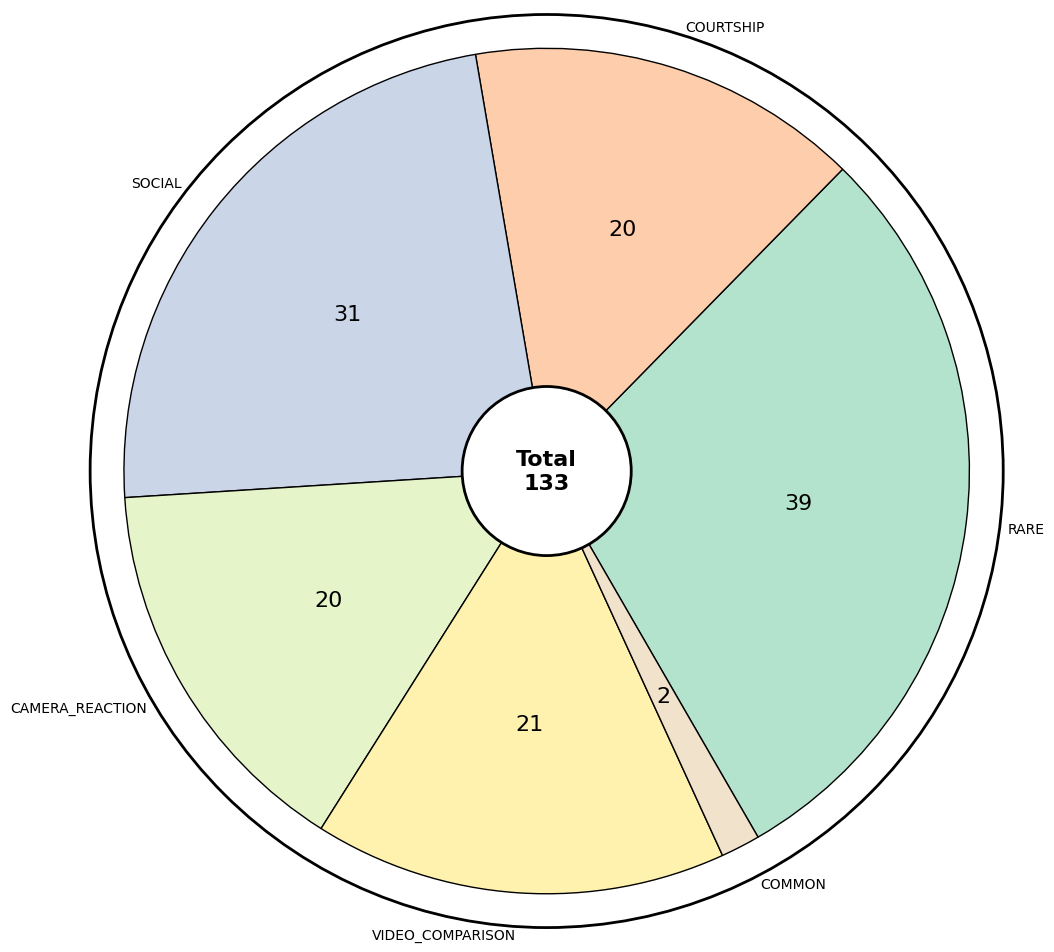

In [12]:
import matplotlib.cm as cm

# Count the number of queries per category
category_counts = {cat: len(queries_and_videos[cat]) for cat in queries_and_videos}
labels = list(category_counts.keys())
sizes = list(category_counts.values())
total_queries = sum(sizes)

# Choose a colormap
cmap = cm.get_cmap('Pastel2')
colors = [cmap(i / len(labels)) for i in range(len(labels))]

# Pie chart with number labels and black edge color
fig, ax = plt.subplots(figsize=(12, 12))
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct=lambda pct: f"{int(round(pct * total_queries / 100))}",
    startangle=300,
    colors=colors,
    wedgeprops=dict(edgecolor='black')
)

# Increase the font size of the number labels on the pie chart
for autotext in autotexts:
    autotext.set_fontsize(16)  # Adjust the value as needed

# Draw a circle at the center with total number of queries
centre_circle = plt.Circle((0, 0), 0.20, fc="white", ec="black", linewidth=2)
ax.add_artist(centre_circle)
ax.text(0, 0, f"Total\n{total_queries}", ha='center', va='center', fontsize=16, fontweight='bold')

outer_circle = plt.Circle((0, 0), 1.08, color='black', fill=False, linewidth=2)
ax.add_artist(outer_circle)

plt.axis('equal')
plt.show()